#  Netflix Titles Dataset EDA

An exploratory data analysis (EDA) of Netflix's movie and TV show catalog. We explore trends by genre, country, release year, ratings, and more.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


##  Load the Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


##  Dataset Overview

In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


##  Missing Values

In [4]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

##  Preprocessing - Date and Year Columns

In [5]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year


##  Movies vs TV Shows

C:\Users\USER\AppData\Local\Temp\ipykernel_3652\4092646432.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


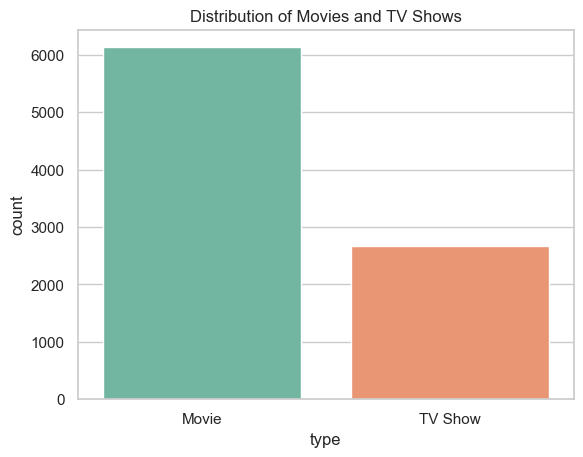

In [6]:
sns.countplot(data=df, x='type', palette='Set2')
plt.title("Distribution of Movies and TV Shows")
plt.show()


##  Titles Added to Netflix Over Time

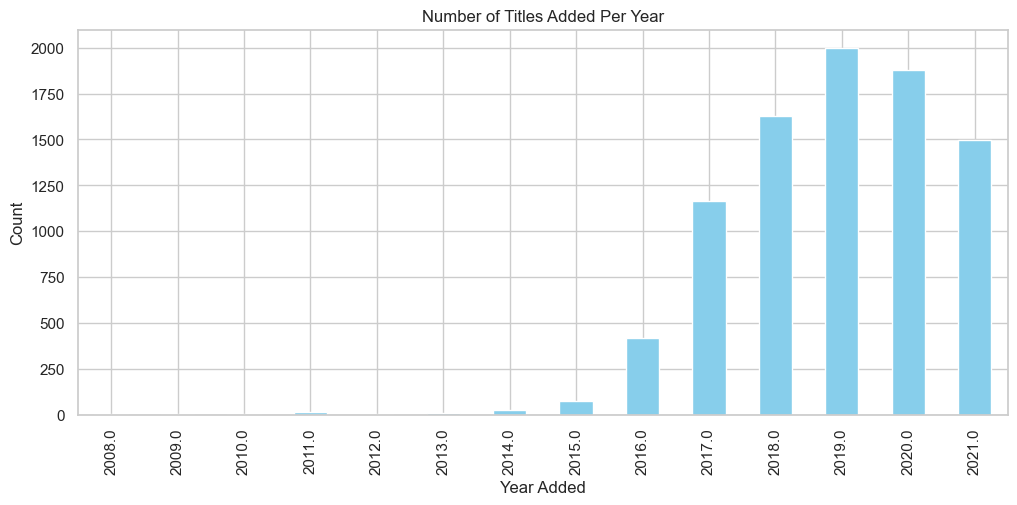

In [7]:
df['year_added'].value_counts().sort_index().plot(kind='bar', figsize=(12, 5), color='skyblue')
plt.title("Number of Titles Added Per Year")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()


##  Ratings Distribution

C:\Users\USER\AppData\Local\Temp\ipykernel_3652\445040257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='pastel')


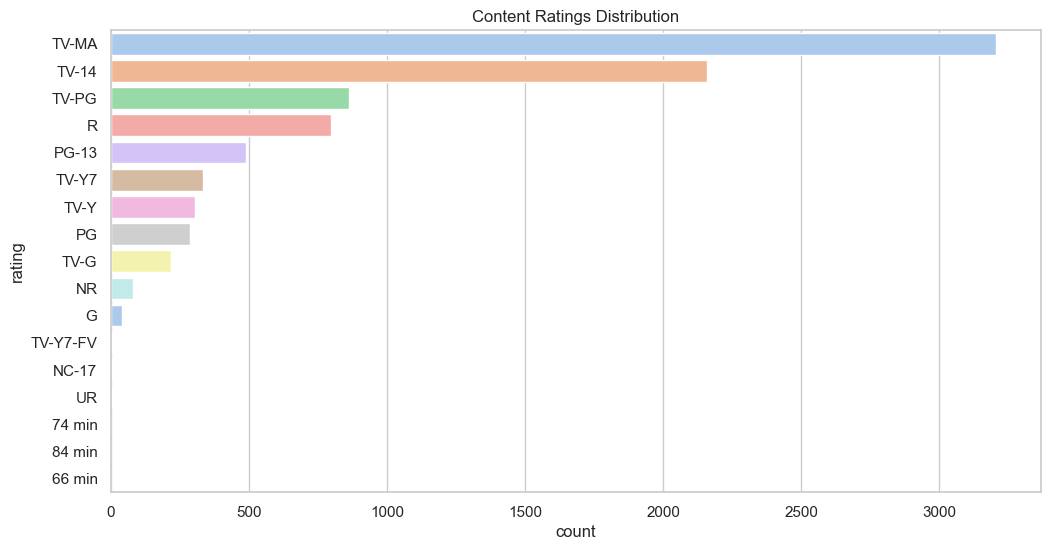

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='pastel')
plt.title("Content Ratings Distribution")
plt.show()


##  Top Producing Countries

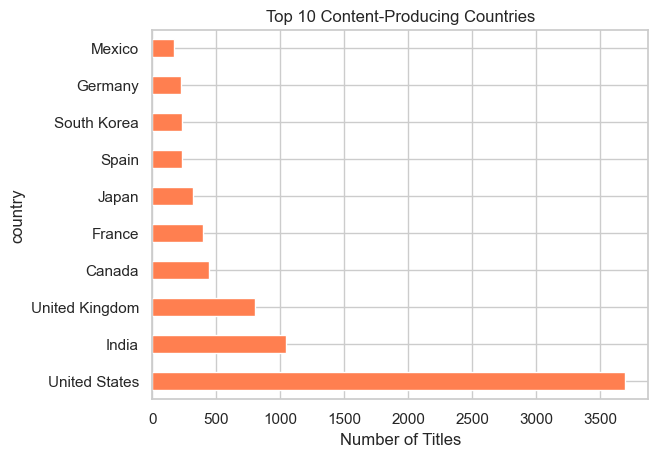

In [9]:
top_countries = df['country'].dropna().str.split(', ').explode().value_counts().head(10)
top_countries.plot(kind='barh', color='coral')
plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles")
plt.show()


##  Top Genres on Netflix

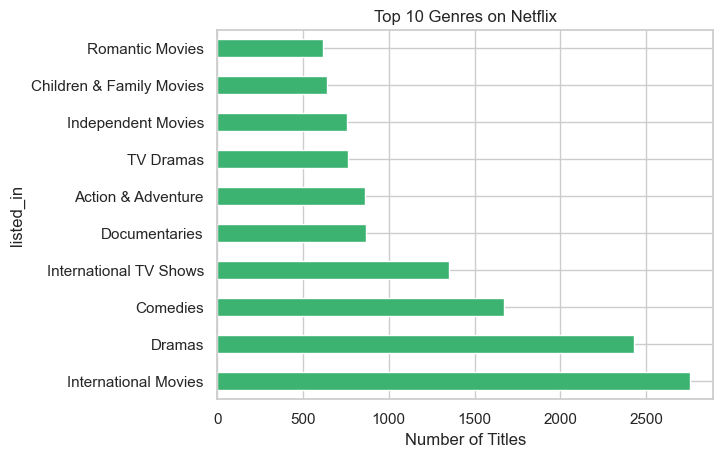

In [10]:
top_genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
top_genres.plot(kind='barh', color='mediumseagreen')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.show()
